# Experiment 05 — complex Keras models for fraud F1 / recall / precision

Standalone Colab notebook. It does not use other experiment notebooks or local project files.

**Data (same recipe as the Kaggle imbalanced-credit kernel)**
1. Scale only Time and Amount with `RobustScaler`.
2. Hold out an original imbalanced test set.
3. Build a 50/50 random undersample (shown, not used for the deep nets — too small).
4. SMOTE the training fold only.
5. Keep a separate original imbalanced **validation** split for honest metric selection.

**Six saved models (same architecture, independent runs)**

| File | Selection |
|---|---|
| `nn_f1_train.keras` | best **train** fraud F1 |
| `nn_f1_val.keras` | best **val** fraud F1 |
| `nn_recall_train.keras` | best **train** fraud recall |
| `nn_recall_val.keras` | best **val** fraud recall |
| `nn_precision_train.keras` | best **train** fraud precision |
| `nn_precision_val.keras` | best **val** fraud precision |

Each run checkpoints the epoch that wins its metric at threshold 0.5, then locks a threshold on that same split. Precision selection requires recall ≥ 0.40 so the model cannot “win” by predicting almost no fraud.

**Saving (Colab best practice)**
- Google Drive: `/content/drive/MyDrive/maktab145/experiment05/`
- Local Colab copy: `/content/experiment05_models/`
- Zip download: `experiment05_models.zip` → copy into this repo as `/experiment05/_models`


In [1]:
%pip install -q kagglehub imbalanced-learn


In [2]:
import json
import shutil
import sys
from pathlib import Path

import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adam

tf.keras.utils.set_random_seed(42)
print("TensorFlow", tf.__version__)
print("GPU", tf.config.list_physical_devices("GPU"))


TensorFlow 2.20.0
GPU []


## Save locations

Mount Drive so weights survive a Colab disconnect. Everything is also written under `/content` and zipped for download into the laptop repo.


In [4]:
LOCAL_DIR = Path("/content/experiment05_models")
LOCAL_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_DIR = None
if "google.colab" in sys.modules:
    from google.colab import drive

    drive.mount("/content/drive")
    DRIVE_DIR = Path("/content/drive/MyDrive/maktab145/experiment05")
    DRIVE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_DIRS = [p for p in (LOCAL_DIR, DRIVE_DIR) if p is not None]
print("Save dirs:", [str(p) for p in SAVE_DIRS])


def persist_file(src: Path):
    for dest_dir in SAVE_DIRS:
        dest_dir.mkdir(parents=True, exist_ok=True)
        dest = dest_dir / src.name
        if dest.resolve() != src.resolve():
            shutil.copy2(src, dest)
    return src


Mounted at /content/drive
Save dirs: ['/content/experiment05_models', '/content/drive/MyDrive/maktab145/experiment05']


## Load data


In [5]:
data_dir = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud"))
csv_candidates = list(data_dir.rglob("creditcard.csv"))
if not csv_candidates:
    raise FileNotFoundError(f"creditcard.csv not found under {data_dir}")
CSV_PATH = csv_candidates[0]
df = pd.read_csv(CSV_PATH)
print("Loaded", CSV_PATH)
print(df.shape)
print(df["Class"].value_counts())
df.head()


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Loaded /kaggle/input/creditcardfraud/creditcard.csv
(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Scale Time and Amount with RobustScaler


In [6]:
rob_scaler = RobustScaler()
df["scaled_amount"] = rob_scaler.fit_transform(df["Amount"].values.reshape(-1, 1))
df["scaled_time"] = rob_scaler.fit_transform(df["Time"].values.reshape(-1, 1))
df.drop(columns=["Time", "Amount"], inplace=True)

scaled_amount = df["scaled_amount"]
scaled_time = df["scaled_time"]
df.drop(columns=["scaled_amount", "scaled_time"], inplace=True)
df.insert(0, "scaled_amount", scaled_amount)
df.insert(1, "scaled_time", scaled_time)

scaler_path = LOCAL_DIR / "robust_scaler.joblib"
joblib.dump(rob_scaler, scaler_path)
persist_file(scaler_path)
print("Amount and Time are scaled")
df.head()


Amount and Time are scaled


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## Original imbalanced splits

Test = last stratified 5-fold (kernel style). Then 20% of remaining train becomes an imbalanced validation set. SMOTE is applied only to the fit split.


In [7]:
print("No Frauds", round(df["Class"].value_counts()[0] / len(df) * 100, 2), "%")
print("Frauds", round(df["Class"].value_counts()[1] / len(df) * 100, 2), "%")

X = df.drop(columns=["Class"])
y = df["Class"]
feature_names = list(X.columns)

sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)
for train_index, test_index in sss.split(X, y):
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]
    fitval_index, heldout_index = train_index, test_index

X_fit_raw, X_val, y_fit_raw, y_val = train_test_split(
    original_Xtrain, original_ytrain, test_size=0.2, random_state=42, stratify=original_ytrain
)

original_Xtest = original_Xtest.values
original_ytest = original_ytest.values
X_fit_raw = X_fit_raw.values
y_fit_raw = y_fit_raw.values
X_val = X_val.values
y_val = y_val.values

print("Fit (raw)", X_fit_raw.shape, "frauds", int(y_fit_raw.sum()))
print("Val      ", X_val.shape, "frauds", int(y_val.sum()))
print("Test     ", original_Xtest.shape, "frauds", int(original_ytest.sum()))

np.savez(
    LOCAL_DIR / "split_indices.npz",
    fitval_index=fitval_index,
    test_index=heldout_index,
    feature_names=np.array(feature_names),
)
persist_file(LOCAL_DIR / "split_indices.npz")


No Frauds 99.83 %
Frauds 0.17 %
Fit (raw) (182276, 30) frauds 315
Val       (45570, 30) frauds 79
Test      (56961, 30) frauds 98


PosixPath('/content/experiment05_models/split_indices.npz')

## Random undersampling (50/50)

Kept to match the research kernel. Not used for the deep models (only ~1k rows).


In [8]:
df_shuffled = df.sample(frac=1, random_state=42)
n_fraud = int((df_shuffled["Class"] == 1).sum())
fraud_df = df_shuffled.loc[df_shuffled["Class"] == 1]
non_fraud_df = df_shuffled.loc[df_shuffled["Class"] == 0][:n_fraud]
new_df = pd.concat([fraud_df, non_fraud_df]).sample(frac=1, random_state=42)
print(new_df["Class"].value_counts())
print("Undersampled shape", new_df.shape)


Class
0    492
1    492
Name: count, dtype: int64
Undersampled shape (984, 31)


## SMOTE on the fit split only


In [9]:
sm = SMOTE(sampling_strategy="minority", random_state=42)
X_fit, y_fit = sm.fit_resample(X_fit_raw, y_fit_raw)
print("Fit raw ", X_fit_raw.shape, np.bincount(y_fit_raw.astype(int)))
print("Fit SMOTE", X_fit.shape, np.bincount(y_fit.astype(int)))


Fit raw  (182276, 30) [181961    315]
Fit SMOTE (363922, 30) [181961 181961]


## Complex network and metric checkpoint

Train metrics are computed on the **original** (not SMOTE) fit split so “best train F1” is not inflated by synthetic rows. Val metrics use the imbalanced validation split.


In [10]:
MIN_RECALL_FOR_PRECISION = 0.40
EPOCHS = 40
BATCH_SIZE = 512
THRESHOLD_GRID = np.round(np.linspace(0.05, 0.95, 91), 4)


def fraud_scores(y_true, proba, threshold=0.5):
    y_pred = (np.asarray(proba).ravel() >= threshold).astype(int)
    y_true = np.asarray(y_true).ravel()
    return {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "tp": int(((y_true == 1) & (y_pred == 1)).sum()),
        "fn": int(((y_true == 1) & (y_pred == 0)).sum()),
        "fp": int(((y_true == 0) & (y_pred == 1)).sum()),
    }


def pick_threshold(y_true, proba, metric):
    best_t, best_s = 0.5, -1.0
    for t in THRESHOLD_GRID:
        s = fraud_scores(y_true, proba, t)
        value = s[metric]
        if metric == "precision" and s["recall"] < MIN_RECALL_FOR_PRECISION:
            continue
        if value > best_s:
            best_s, best_t = value, float(t)
    return best_t, best_s


def build_complex_model(n_inputs):
    model = Sequential([
        Input(shape=(n_inputs,)),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.35),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.30),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.25),
        Dense(32, activation="relu"),
        Dropout(0.15),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


class FraudMetricCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, X_ref, y_ref, split, metric, save_path, patience=10):
        super().__init__()
        self.X_ref = X_ref
        self.y_ref = y_ref
        self.split = split
        self.metric = metric
        self.save_path = Path(save_path)
        self.patience = patience
        self.best = -1.0
        self.best_epoch = 0
        self.wait = 0
        self.history = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        proba = self.model.predict(self.X_ref, batch_size=2048, verbose=0).ravel()
        scores = fraud_scores(self.y_ref, proba, 0.5)
        for k, v in scores.items():
            if k in {"precision", "recall", "f1"}:
                logs[f"{self.split}_{k}"] = v
        current = scores[self.metric]
        row = {"epoch": int(epoch + 1), **scores}
        self.history.append(row)
        improved = current > self.best + 1e-6
        if improved:
            self.best = current
            self.best_epoch = int(epoch + 1)
            self.wait = 0
            self.save_path.parent.mkdir(parents=True, exist_ok=True)
            self.model.save(self.save_path)
            persist_file(self.save_path)
            print(
                f"  saved {self.save_path.name} @ epoch {self.best_epoch}: "
                f"{self.split} {self.metric}={current:.4f} "
                f"(P={scores['precision']:.4f} R={scores['recall']:.4f})"
            )
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True
                print(f"  early stop on {self.split} {self.metric} (best={self.best:.4f})")


## Train the six models

Each run is a fresh network. Checkpoint + early stopping use only that run’s target split and metric. After training, the decision threshold is locked on the same split.


In [11]:
SPECS = [
    ("f1", "train"),
    ("f1", "val"),
    ("recall", "train"),
    ("recall", "val"),
    ("precision", "train"),
    ("precision", "val"),
]

split_data = {
    "train": (X_fit_raw, y_fit_raw),
    "val": (X_val, y_val),
}

manifest = {"models": {}, "min_recall_for_precision": MIN_RECALL_FOR_PRECISION}
histories = {}

build_complex_model(X_fit.shape[1]).summary()

for metric, split in SPECS:
    name = f"nn_{metric}_{split}"
    print("\n" + "=" * 80)
    print("Training", name)
    print("=" * 80)
    save_path = LOCAL_DIR / f"{name}.keras"
    X_ref, y_ref = split_data[split]
    ckpt = FraudMetricCheckpoint(
        X_ref=X_ref,
        y_ref=y_ref,
        split=split,
        metric=metric,
        save_path=save_path,
        patience=10,
    )
    model = build_complex_model(X_fit.shape[1])
    callbacks = [
        ckpt,
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ]
    model.fit(
        X_fit, y_fit,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=2,
        callbacks=callbacks,
    )
    if not save_path.exists():
        model.save(save_path)
        persist_file(save_path)

    best_model = load_model(save_path)
    ref_proba = best_model.predict(X_ref, batch_size=2048, verbose=0).ravel()
    best_t, best_s = pick_threshold(y_ref, ref_proba, metric)
    test_proba = best_model.predict(original_Xtest, batch_size=2048, verbose=0).ravel()
    test_at_05 = fraud_scores(original_ytest, test_proba, 0.5)
    test_at_t = fraud_scores(original_ytest, test_proba, best_t)

    hist_path = LOCAL_DIR / f"{name}_history.json"
    hist_path.write_text(json.dumps(ckpt.history, indent=2))
    persist_file(hist_path)

    record = {
        "file": save_path.name,
        "metric": metric,
        "split": split,
        "best_epoch_at_0.5": ckpt.best_epoch,
        "best_split_score_at_0.5": ckpt.best,
        "locked_threshold": best_t,
        "split_score_at_locked_threshold": best_s,
        "test_at_0.5": test_at_05,
        "test_at_locked_threshold": test_at_t,
    }
    manifest["models"][name] = record
    histories[name] = ckpt.history
    print(
        f"Locked t={best_t:.2f} on {split} {metric}={best_s:.4f} | "
        f"TEST F1={test_at_t['f1']:.4f} P={test_at_t['precision']:.4f} "
        f"R={test_at_t['recall']:.4f}"
    )

manifest_path = LOCAL_DIR / "manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))
persist_file(manifest_path)
print("\nWrote manifest.json")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,993 (207.00 KB)

 Trainable params: 52,097 (203.50 KB)

 Non-trainable params: 896 (3.50 KB)


Training nn_f1_train
Epoch 1/40
  saved nn_f1_train.keras @ epoch 1: train f1=0.4965 (P=0.3302 R=1.0000)
711/711 - 19s - 27ms/step - accuracy: 0.9840 - loss: 0.0446 - val_accuracy: 0.9964 - val_loss: 0.0132 - train_precision: 0.3302 - train_recall: 1.0000 - train_f1: 0.4965 - learning_rate: 0.0010
Epoch 2/40
  saved nn_f1_train.keras @ epoch 2: train f1=0.7300 (P=0.5748 R=1.0000)
711/711 - 16s - 22ms/step - accuracy: 0.9972 - loss: 0.0101 - val_accuracy: 0.9984 - val_loss: 0.0077 - train_precision: 0.5748 - train_recall: 1.0000 - train_f1: 0.7300 - learning_rate: 0.0010
Epoch 3/40
  saved nn_f1_train.keras @ epoch 3: train f1=0.7309 (P=0.5759 R=1.0000)
711/711 - 15s - 21ms/step - accuracy: 0.9982 - loss: 0.0071 - val_accuracy: 0.9983 - val_loss: 0.0077 - train_precision: 0.5759 - train_recall: 1.0000 - train_f1: 0.7309 - learning_rate: 0.0010
Epoch 4/40
  saved nn_f1_train.keras @ epoch 4: train f1=0.8119 (P=0.6833 R=1.0000)
711/711 - 14s - 20ms/step - accuracy: 0.9987 - loss: 0.0054 

## Test comparison

Locked thresholds come from train or val only. Test is not used to pick models.


In [12]:
rows = []
for name, rec in manifest["models"].items():
    t = rec["test_at_locked_threshold"]
    rows.append({
        "model": name,
        "optimize": f"{rec['metric']} on {rec['split']}",
        "threshold": rec["locked_threshold"],
        "test_precision": t["precision"],
        "test_recall": t["recall"],
        "test_f1": t["f1"],
        "tp": t["tp"],
        "fn": t["fn"],
        "fp": t["fp"],
    })
compare = pd.DataFrame(rows).sort_values("test_f1", ascending=False)
print(compare.round(4).to_string(index=False))
compare_path = LOCAL_DIR / "test_comparison.csv"
compare.to_csv(compare_path, index=False)
persist_file(compare_path)

best_name = compare.iloc[0]["model"]
best_rec = manifest["models"][best_name]
print("\nBest test F1 so far:", best_name)
print(classification_report(
    original_ytest,
    (load_model(LOCAL_DIR / best_rec["file"]).predict(original_Xtest, batch_size=2048, verbose=0).ravel()
     >= best_rec["locked_threshold"]).astype(int),
    target_names=["No Fraud", "Fraud"],
    zero_division=0,
))


             model           optimize  threshold  test_precision  test_recall  test_f1  tp  fn  fp
nn_precision_train precision on train       0.90          0.9583       0.7041   0.8118  69  29   3
         nn_f1_val          f1 on val       0.91          0.9306       0.6837   0.7882  67  31   5
       nn_f1_train        f1 on train       0.95          0.9178       0.6837   0.7836  67  31   6
  nn_precision_val   precision on val       0.80          0.9296       0.6735   0.7811  66  32   5
   nn_recall_train    recall on train       0.05          0.2718       0.8265   0.4091  81  17 217
     nn_recall_val      recall on val       0.05          0.2531       0.8265   0.3876  81  17 239

Best test F1 so far: nn_precision_train
              precision    recall  f1-score   support

    No Fraud       1.00      1.00      1.00     56863
       Fraud       0.96      0.70      0.81        98

    accuracy                           1.00     56961
   macro avg       0.98      0.85      0.91     

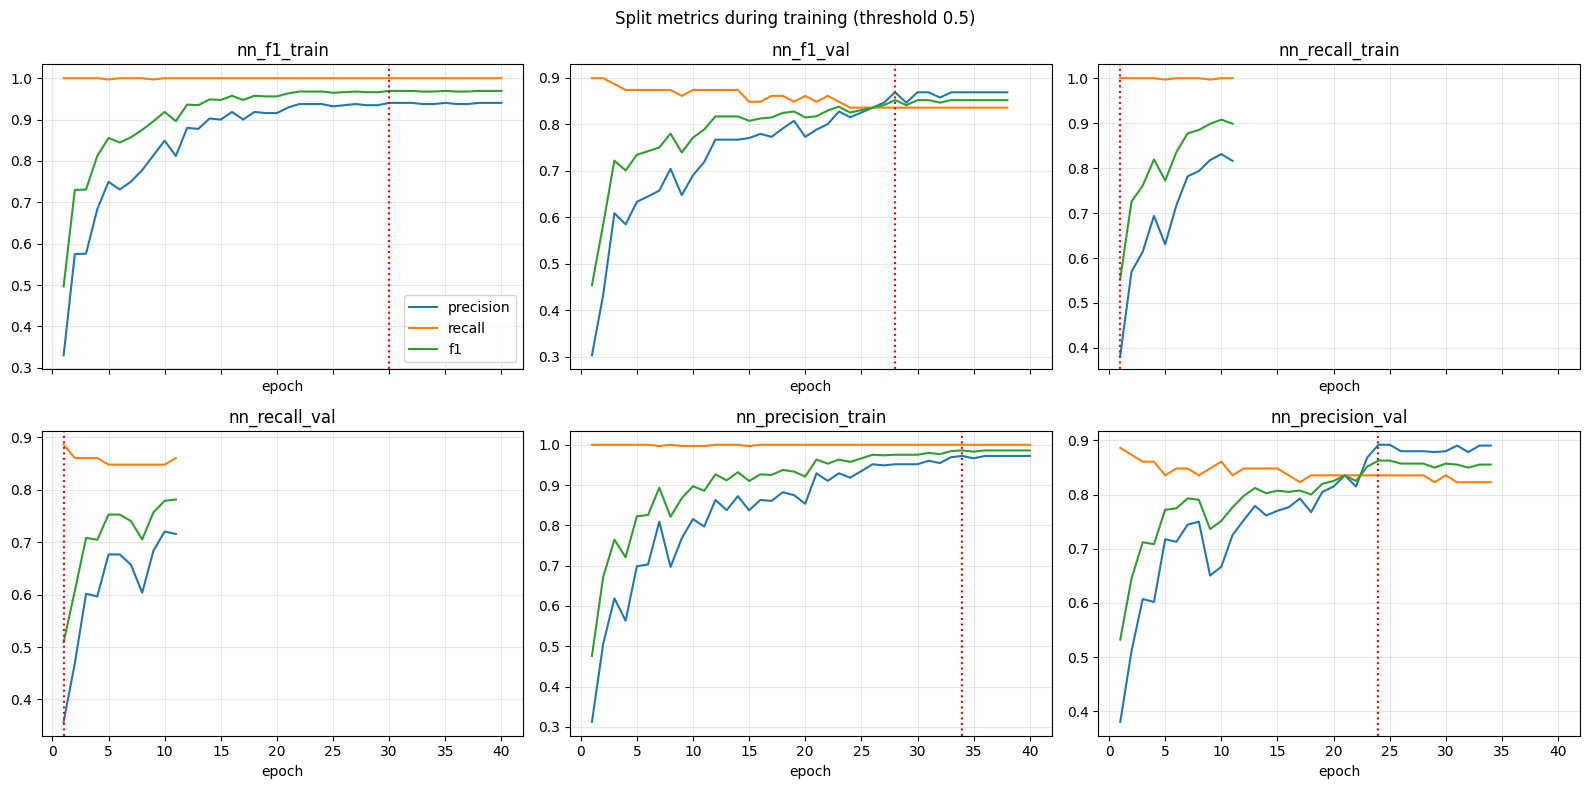

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for ax, (metric, split) in zip(axes.ravel(), SPECS):
    name = f"nn_{metric}_{split}"
    hist = pd.DataFrame(histories[name])
    ax.plot(hist["epoch"], hist["precision"], label="precision")
    ax.plot(hist["epoch"], hist["recall"], label="recall")
    ax.plot(hist["epoch"], hist["f1"], label="f1")
    ax.axvline(manifest["models"][name]["best_epoch_at_0.5"], color="red", linestyle=":")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("epoch")
axes[0, 0].legend()
fig.suptitle("Split metrics during training (threshold 0.5)")
plt.tight_layout()
plt.show()


## Zip and download

On the laptop, unzip into `_models/experiment05/`. You should have six `.keras` files, `robust_scaler.joblib`, `manifest.json`, histories, and `test_comparison.csv`.


In [14]:
zip_base = Path("/content/experiment05_models")
shutil.make_archive(str(zip_base), "zip", root_dir=LOCAL_DIR)
zip_path = Path("/content/experiment05_models.zip")
persist_file(zip_path)
print("Zip:", zip_path, "size_mb", round(zip_path.stat().st_size / 1e6, 2))
print("Drive folder:", DRIVE_DIR)

if "google.colab" in sys.modules:
    from google.colab import files

    files.download(str(zip_path))


Zip: /content/experiment05_models.zip size_mb 3.99
Drive folder: /content/drive/MyDrive/maktab145/experiment05


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>